In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [32]:
BASE_DIR = Path.cwd().parent

TRAIN_DIR = BASE_DIR / "data" / "plant_disease" / "raw" / "PlantVillage" / "train"

VAL_DIR = BASE_DIR / "data" / "plant_disease" / "raw" / "PlantVillage" / "val"

print("Training path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)

print("\nTraining path exists:", TRAIN_DIR.exists())
print("Validation path exists:", VAL_DIR.exists())

Training path: c:\Users\janap\OneDrive\Documents\Desktop\AgriVoice\data\plant_disease\raw\PlantVillage\train
Validation path: c:\Users\janap\OneDrive\Documents\Desktop\AgriVoice\data\plant_disease\raw\PlantVillage\val

Training path exists: True
Validation path exists: True


In [ ]:
SELECTED_CLASSES = [
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Pepper,_bell___Bacterial_spot",
    "Pepper,_bell___healthy"
]

print("Number of selected classes:", len(SELECTED_CLASSES))

Number of selected classes: 8


In [ ]:
from collections import Counter

train_counts = {}
val_counts = {}

for class_name in SELECTED_CLASSES:
    
    train_class_path = TRAIN_DIR / class_name
    val_class_path = VAL_DIR / class_name
    
    # Count training images
    train_counts[class_name] = len(
        list(train_class_path.glob("*"))
    )
    
    # Count validation images
    val_counts[class_name] = len(
        list(val_class_path.glob("*"))
    )

print("TRAINING IMAGES:")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

print("\nVALIDATION IMAGES:")
for class_name, count in val_counts.items():
    print(f"{class_name}: {count}")

TRAINING IMAGES:
Tomato___Bacterial_spot: 1702
Tomato___Early_blight: 800
Tomato___Late_blight: 1527
Tomato___healthy: 1273
Potato___Early_blight: 800
Potato___Late_blight: 800
Pepper,_bell___Bacterial_spot: 797
Pepper,_bell___healthy: 1183

VALIDATION IMAGES:
Tomato___Bacterial_spot: 425
Tomato___Early_blight: 200
Tomato___Late_blight: 382
Tomato___healthy: 318
Potato___Early_blight: 200
Potato___Late_blight: 200
Pepper,_bell___Bacterial_spot: 200
Pepper,_bell___healthy: 295


In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=SELECTED_CLASSES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 8882 files belonging to 8 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=SELECTED_CLASSES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2220 files belonging to 8 classes.


In [ ]:
print("Class Names:")
print(train_ds.class_names)

print("\nNumber of training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Number of validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Class Names:
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy']

Number of training batches: 278
Number of validation batches: 70


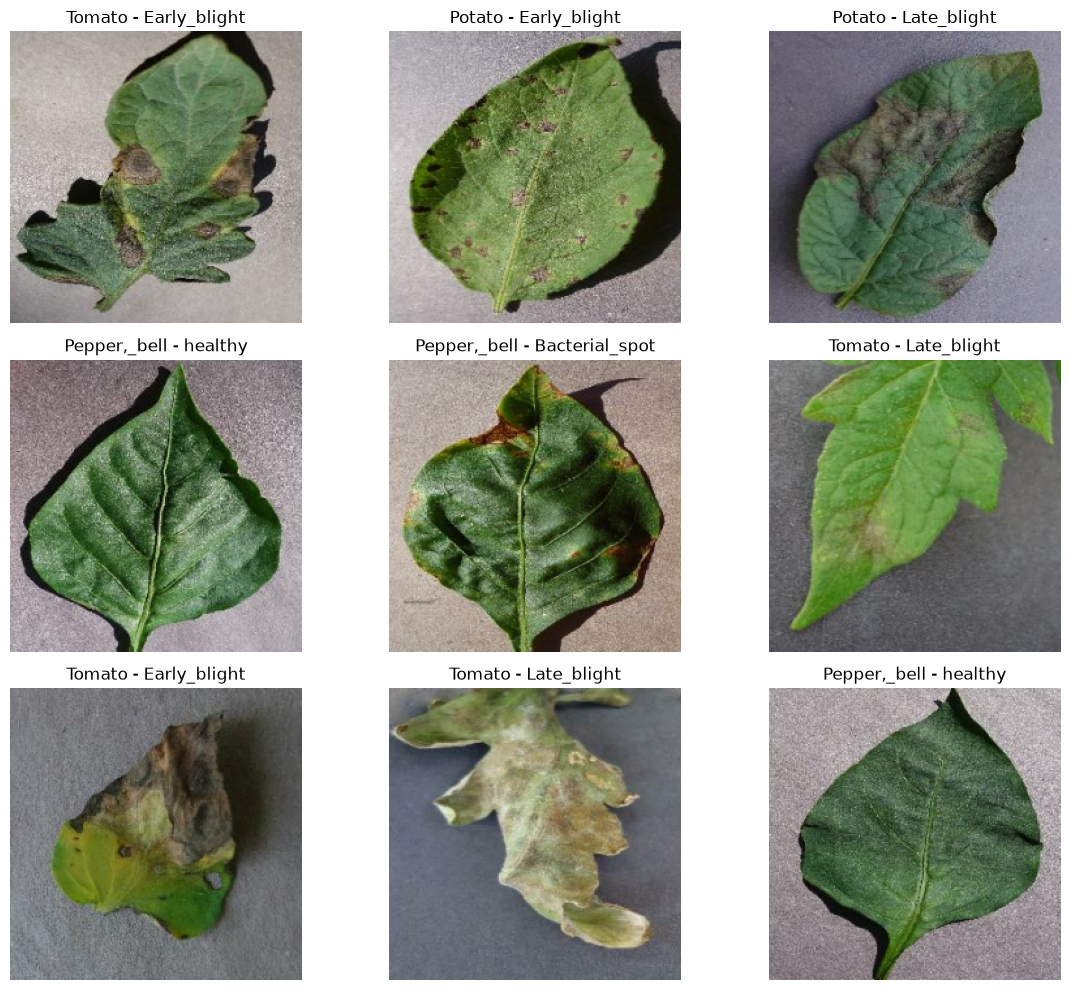

In [ ]:
plt.figure(figsize=(12, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        class_name = train_ds.class_names[labels[i]]
        plt.title(class_name.replace("___", " - "))
        
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation layer created successfully!")

Data augmentation layer created successfully!


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 base model loaded successfully!")

MobileNetV2 base model loaded successfully!


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Pretrained feature extraction
x = base_model(x, training=False)

# Convert feature maps to a single feature vector
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Prevent overfitting
x = tf.keras.layers.Dropout(0.2)(x)

# Final classification layer
outputs = tf.keras.layers.Dense(
    8,
    activation="softmax"
)(x)

disease_model = tf.keras.Model(inputs, outputs)

disease_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
disease_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
EPOCHS = 10

history = disease_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/10


105/278 ━━━━━━━━━━━━━━━━━━━━ 2:01 703ms/step - accuracy: 0.6711 - loss: 0.9950

In [ ]:
val_loss, val_accuracy = disease_model.evaluate(val_ds)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

NameError: name 'disease_model' is not defined